# Otros Modelos de ML — PH2

## 1. Configuración e imports

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    GridSearchCV,
    cross_val_predict,
    cross_val_score
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    average_precision_score
)

import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.preprocessing.image import load_img, img_to_array

warnings.filterwarnings("ignore")
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

BASE_PATH   = "/home/carlos/Git/DatasetPH2-model/PH2Dataset"
IMAGES_DIR  = os.path.join(BASE_PATH, "PH2 Dataset images")
XLSX_PATH   = os.path.join(BASE_PATH, "PH2_dataset.xlsx")
IMG_SIZE    = (224, 224)

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110
print("Imports OK — TF:", tf.__version__)


I0000 00:00:1780474940.802399   11092 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Imports OK — TF: 2.21.0


## 2. Carga de metadata PH2 y construcción del target

In [2]:
df_raw = pd.read_excel(XLSX_PATH, skiprows=12)
df_raw.columns = df_raw.columns.str.strip()
df = df_raw[df_raw["Image Name"].notna()].copy()
df = df[df["Image Name"].astype(str).str.startswith("IMD")].copy()

def extraer_diagnostico(row):
    if str(row.get("Melanoma", "")).strip().upper() == "X":
        return "Melanoma"
    elif str(row.get("Atypical Nevus", "")).strip().upper() == "X":
        return "Atypical Nevus"
    elif str(row.get("Common Nevus", "")).strip().upper() == "X":
        return "Common Nevus"
    return "Unknown"

df["Diagnosis"] = df.apply(extraer_diagnostico, axis=1)
df = df[df["Diagnosis"] != "Unknown"].copy().reset_index(drop=True)

CLASS_MAP = {"Common Nevus": 0, "Atypical Nevus": 1, "Melanoma": 2}
CLASS_NAMES = ["Common Nevus", "Atypical Nevus", "Melanoma"]
df["y"] = df["Diagnosis"].map(CLASS_MAP)

print("Total muestras:", len(df))
print(df["Diagnosis"].value_counts())


Total muestras: 200
Diagnosis
Common Nevus      80
Atypical Nevus    80
Melanoma          40
Name: count, dtype: int64


## 3. Resolución de rutas de imagen (.bmp)

In [3]:
def construir_ruta_imagen(image_id):
    return os.path.join(
        IMAGES_DIR,
        image_id,
        f"{image_id}_Dermoscopic_Image",
        f"{image_id}.bmp"
    )

df["image_path"] = df["Image Name"].astype(str).apply(construir_ruta_imagen)

missing = df[~df["image_path"].apply(os.path.exists)]
if len(missing) > 0:
    print(f"⚠ Imágenes faltantes: {len(missing)}")
    display(missing[["Image Name", "image_path"]].head())
else:
    print("✓ Todas las imágenes encontradas")

df = df[df["image_path"].apply(os.path.exists)].reset_index(drop=True)
print("Muestras válidas:", len(df))


✓ Todas las imágenes encontradas
Muestras válidas: 200


## 4. Carga y preprocesamiento de imágenes

In [4]:
def load_and_preprocess(path, size=(224, 224)):
    img = load_img(path, target_size=size)
    arr = img_to_array(img)
    return preprocess_input(arr)

print("Cargando imágenes...")
X_img = np.array([
    load_and_preprocess(p, IMG_SIZE)
    for p in df["image_path"]
], dtype=np.float32)

y = df["y"].values
print(f"Shape imágenes: {X_img.shape}")
print(f"Distribución de clases: {np.bincount(y)}")


Cargando imágenes...
Shape imágenes: (200, 224, 224, 3)
Distribución de clases: [80 80 40]


## 5. Extracción de features con ResNet50 (extractor puro)

Se usa ResNet50 con pesos de ImageNet como **extractor de características** (sin fine-tuning).
El `GlobalAveragePooling2D` produce un vector de **2048 dimensiones** por imagen.


In [5]:
extractor = ResNet50(
    weights="imagenet",
    include_top=False,
    pooling="avg",
    input_shape=(224, 224, 3)
)
extractor.trainable = False  # Congelado completamente

print("Extrayendo deep features (puede tardar ~1 min)...")
X_features = extractor.predict(X_img, batch_size=16, verbose=1)
print(f"Shape features: {X_features.shape}")  # (200, 2048)


I0000 00:00:1780474942.721057   11092 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 7496 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1080, pci bus id: 0000:01:00.0, compute capability: 6.1


Extrayendo deep features (puede tardar ~1 min)...


I0000 00:00:1780474945.459110   11172 service.cc:153] XLA service 0x7f28600e65a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780474945.459133   11172 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce GTX 1080, Compute Capability 6.1 (Driver: 13.0.0; Runtime: 12.4.0; Toolkit: 12.5.0; DNN: 9.10.1)
I0000 00:00:1780474945.513261   11172 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1780474945.941119   11172 cuda_dnn.cc:461] Loaded cuDNN version 91001


 5/13 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step

I0000 00:00:1780474949.051511   11172 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


13/13 ━━━━━━━━━━━━━━━━━━━━ 8s 312ms/step
Shape features: (200, 2048)


## 6. División de datos: Train / Validación / Test

Split estratificado en **3 partes**:
- **60% Entrenamiento** — para GridSearchCV
- **20% Validación** — para selección del modelo final
- **20% Test hold-out** — evaluación final, una sola vez

Se preservan las proporciones de clase en cada split.


In [6]:
# Paso 1: separar test hold-out (20%)
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X_features, y,
    test_size=0.20,
    stratify=y,
    random_state=SEED
)

# Paso 2: separar train / validación del 80% restante
# 0.20 / 0.80 = 0.25 para obtener 20% del total
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval,
    test_size=0.25,
    stratify=y_trainval,
    random_state=SEED
)

print(f"Entrenamiento : {len(X_train):3d} muestras — clases {np.bincount(y_train)}")
print(f"Validación    : {len(X_val):3d} muestras — clases {np.bincount(y_val)}")
print(f"Test hold-out : {len(X_test):3d} muestras — clases {np.bincount(y_test)}")
print(f"\nTotal: {len(X_train)+len(X_val)+len(X_test)}")


Entrenamiento : 120 muestras — clases [48 48 24]
Validación    :  40 muestras — clases [16 16  8]
Test hold-out :  40 muestras — clases [16 16  8]

Total: 200


## 7. Funciones auxiliares de evaluación

In [7]:
def evaluar_modelo(nombre, modelo, X, y_true):
    """Evalúa un modelo sobre un conjunto dado. Retorna dict de métricas."""
    y_pred  = modelo.predict(X)
    y_proba = modelo.predict_proba(X)

    y_bin    = (y_true == 2).astype(int)
    y_p_bin  = (y_pred  == 2).astype(int)
    p_mel    = y_proba[:, 2]

    acc      = accuracy_score(y_true, y_pred)
    bal_acc  = balanced_accuracy_score(y_true, y_pred)
    f1_macro = f1_score(y_true, y_pred, average="macro", zero_division=0)
    f1_mel   = f1_score(y_bin,  y_p_bin, zero_division=0)
    auc_mel  = roc_auc_score(y_bin, p_mel)
    ap_mel   = average_precision_score(y_bin, p_mel)

    tn = ((y_bin == 0) & (y_p_bin == 0)).sum()
    fp = ((y_bin == 0) & (y_p_bin == 1)).sum()
    fn = ((y_bin == 1) & (y_p_bin == 0)).sum()
    tp = ((y_bin == 1) & (y_p_bin == 1)).sum()

    sens = tp / (tp + fn) if (tp + fn) > 0 else 0
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0

    return {
        "Modelo"         : nombre,
        "Accuracy"       : round(acc,      4),
        "Bal Accuracy"   : round(bal_acc,  4),
        "F1 Macro"       : round(f1_macro, 4),
        "F1 Melanoma"    : round(f1_mel,   4),
        "AUC Melanoma"   : round(auc_mel,  4),
        "AP Melanoma"    : round(ap_mel,   4),
        "Sensibilidad"   : round(sens,     4),
        "Especificidad"  : round(spec,     4),
    }

print("Funciones cargadas")


Funciones cargadas


## 8. Definición de modelos y grillas de hiperparámetros

Se usa `Pipeline(scaler → clf)` para garantizar que el escalado ocurra
**dentro de cada fold** de la validación cruzada (evita fuga de información).

Las grillas han sido expandidas para cubrir un rango amplio de hiperparámetros.


In [8]:
cv_inner = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

modelos_config = {

    "SVM Lineal": {
        "pipeline": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", SVC(
                kernel="linear",
                probability=True,
                class_weight="balanced",
                random_state=SEED,
                max_iter=10000
            ))
        ]),
        "param_grid": {
            "clf__C": [1e-3, 1e-2, 0.05, 0.1, 0.5, 1, 5, 10, 50, 100],
        }
    },

    "SVM RBF": {
        "pipeline": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", SVC(
                kernel="rbf",
                probability=True,
                class_weight="balanced",
                random_state=SEED
            ))
        ]),
        "param_grid": {
            "clf__C"    : [0.01, 0.1, 1, 5, 10, 50, 100],
            "clf__gamma": ["scale", "auto", 1e-4, 1e-3, 0.01, 0.1],
        }
    },

    "Regresión Logística": {
        "pipeline": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(
                class_weight="balanced",
                random_state=SEED,
                max_iter=10000,
                multi_class="ovr"
            ))
        ]),
        "param_grid": {
            "clf__C"      : [1e-4, 1e-3, 0.01, 0.1, 0.5, 1, 5, 10, 50],
            "clf__solver" : ["lbfgs", "saga"],
            "clf__penalty": ["l2"],
        }
    },

    "Árbol de Decisión": {
        "pipeline": Pipeline([
            ("clf", DecisionTreeClassifier(
                class_weight="balanced",
                random_state=SEED
            ))
        ]),
        "param_grid": {
            "clf__max_depth"        : [3, 4, 5, 6, 8, 10, 15, None],
            "clf__min_samples_split": [2, 5, 10, 20],
            "clf__min_samples_leaf" : [1, 2, 4, 8],
            "clf__criterion"        : ["gini", "entropy"],
            "clf__max_features"     : ["sqrt", "log2", None],
            "clf__ccp_alpha"        : [0.0, 0.001, 0.01, 0.05],
        }
    },
}

print("Modelos y grillas definidas")
for nombre, cfg in modelos_config.items():
    n_combos = 1
    for v in cfg["param_grid"].values():
        n_combos *= len(v)
    print(f"  {nombre:25s}: {n_combos} combinaciones × 5 folds = {n_combos*5} fits")


Modelos y grillas definidas
  SVM Lineal               : 10 combinaciones × 5 folds = 50 fits
  SVM RBF                  : 42 combinaciones × 5 folds = 210 fits
  Regresión Logística      : 18 combinaciones × 5 folds = 90 fits
  Árbol de Decisión        : 3072 combinaciones × 5 folds = 15360 fits


## 9. GridSearchCV sobre el conjunto de entrenamiento

El grid search usa **K-Fold interno (k=5)** sobre el training set.
El scoring primario es **F1 Macro** (equilibrado con clases desbalanceadas).


In [9]:
resultados_grid  = {}
resultados_cv    = []

for nombre, cfg in modelos_config.items():
    print(f"\n{'─'*70}")
    print(f"  Buscando: {nombre}")
    print(f"{'─'*70}")

    grid = GridSearchCV(
        estimator    = cfg["pipeline"],
        param_grid   = cfg["param_grid"],
        scoring      = "f1_macro",
        cv           = cv_inner,
        n_jobs       = -1,
        refit        = True,
        verbose      = 1,
        return_train_score = False
    )
    grid.fit(X_train, y_train)

    best = grid.best_estimator_

    # Guardar para evaluación posterior
    resultados_grid[nombre] = {
        "grid"        : grid,
        "best_model"  : best,
        "best_params" : grid.best_params_,
        "best_cv_f1"  : grid.best_score_,
    }

    # Métricas en validación (elegir modelo final aquí)
    metricas_val = evaluar_modelo(nombre, best, X_val, y_val)
    metricas_val["Best Params"] = str(grid.best_params_)
    metricas_val["CV F1 Macro"] = round(grid.best_score_, 4)
    resultados_cv.append(metricas_val)

    print(f"  - Mejores params: {grid.best_params_}")
    print(f"  - CV F1 Macro (train): {grid.best_score_:.4f}")
    print(f"  - Val AUC Melanoma:    {metricas_val['AUC Melanoma']:.4f}")

tabla_val = pd.DataFrame(resultados_cv).sort_values("AUC Melanoma", ascending=False)
print("\n" + "═"*80)
print("RESULTADOS EN VALIDACIÓN (ordenados por AUC Melanoma)")
print("═"*80)
display(tabla_val[[
    "Modelo", "CV F1 Macro", "Accuracy", "F1 Macro",
    "F1 Melanoma", "AUC Melanoma", "Sensibilidad", "Especificidad"
]])



──────────────────────────────────────────────────────────────────────
  Buscando: SVM Lineal
──────────────────────────────────────────────────────────────────────
Fitting 5 folds for each of 10 candidates, totalling 50 fits
  - Mejores params: {'clf__C': 0.01}
  - CV F1 Macro (train): 0.6228
  - Val AUC Melanoma:    0.9766

──────────────────────────────────────────────────────────────────────
  Buscando: SVM RBF
──────────────────────────────────────────────────────────────────────
Fitting 5 folds for each of 42 candidates, totalling 210 fits
  - Mejores params: {'clf__C': 50, 'clf__gamma': 0.0001}
  - CV F1 Macro (train): 0.6183
  - Val AUC Melanoma:    0.9766

──────────────────────────────────────────────────────────────────────
  Buscando: Regresión Logística
──────────────────────────────────────────────────────────────────────
Fitting 5 folds for each of 18 candidates, totalling 90 fits
  - Mejores params: {'clf__C': 0.5, 'clf__penalty': 'l2', 'clf__solver': 'lbfgs'}
  - CV F

,Modelo,CV F1 Macro,Accuracy,F1 Macro,F1 Melanoma,AUC Melanoma,Sensibilidad,Especificidad
0,SVM Lineal,0.6228,0.725,0.7459,0.8889,0.9766,1.000,0.9375
1,SVM RBF,0.6183,0.700,0.7282,0.8750,0.9766,0.875,0.9688
2,Regresión Logística,0.5966,0.725,0.7412,0.8235,0.9727,0.875,0.9375
3,Árbol de Decisión,0.5885,0.575,0.5667,0.6364,0.8691,0.875,0.7812


## 10. Evaluación final en Test hold-out

El test hold-out se evalúa **una sola vez** con el mejor modelo de cada tipo
(ya seleccionado por GridSearchCV + validación).


In [10]:
resultados_test = []
roc_data        = {}

for nombre, info in resultados_grid.items():
    modelo   = info["best_model"]
    metricas = evaluar_modelo(nombre, modelo, X_test, y_test)
    resultados_test.append(metricas)

    # ROC data para gráfico
    y_test_bin = (y_test == 2).astype(int)
    p_mel      = modelo.predict_proba(X_test)[:, 2]
    fpr, tpr, _ = roc_curve(y_test_bin, p_mel)
    roc_data[nombre] = (fpr, tpr, metricas["AUC Melanoma"])

    # Reporte completo
    print(f"\n{'─'*70}")
    print(f"  Modelo: {nombre}")
    print(f"  Params: {info['best_params']}")
    print(f"{'─'*70}")
    print(classification_report(
        y_test,
        modelo.predict(X_test),
        target_names=CLASS_NAMES,
        zero_division=0
    ))

tabla_test = pd.DataFrame(resultados_test).sort_values("AUC Melanoma", ascending=False)
print("\n" + "═"*80)
print("RESULTADOS EN TEST HOLD-OUT (ordenados por AUC Melanoma)")
print("═"*80)
display(tabla_test)



──────────────────────────────────────────────────────────────────────
  Modelo: SVM Lineal
  Params: {'clf__C': 0.01}
──────────────────────────────────────────────────────────────────────
                precision    recall  f1-score   support

  Common Nevus       0.82      0.56      0.67        16
Atypical Nevus       0.60      0.75      0.67        16
      Melanoma       0.78      0.88      0.82         8

      accuracy                           0.70        40
     macro avg       0.73      0.73      0.72        40
  weighted avg       0.72      0.70      0.70        40


──────────────────────────────────────────────────────────────────────
  Modelo: SVM RBF
  Params: {'clf__C': 50, 'clf__gamma': 0.0001}
──────────────────────────────────────────────────────────────────────
                precision    recall  f1-score   support

  Common Nevus       0.78      0.44      0.56        16
Atypical Nevus       0.54      0.81      0.65        16
      Melanoma       0.86      0.75  

,Modelo,Accuracy,Bal Accuracy,F1 Macro,F1 Melanoma,AUC Melanoma,AP Melanoma,Sensibilidad,Especificidad
1,SVM RBF,0.650,0.6667,0.6700,0.8000,0.9844,0.9318,0.750,0.9688
0,SVM Lineal,0.700,0.7292,0.7190,0.8235,0.9766,0.9116,0.875,0.9375
2,Regresión Logística,0.625,0.6250,0.6347,0.6667,0.9414,0.7594,0.625,0.9375
3,Árbol de Decisión,0.500,0.4792,0.4790,0.4286,0.6406,0.3125,0.375,0.9062


## 11. Curvas ROC comparativas — Melanoma vs No Melanoma

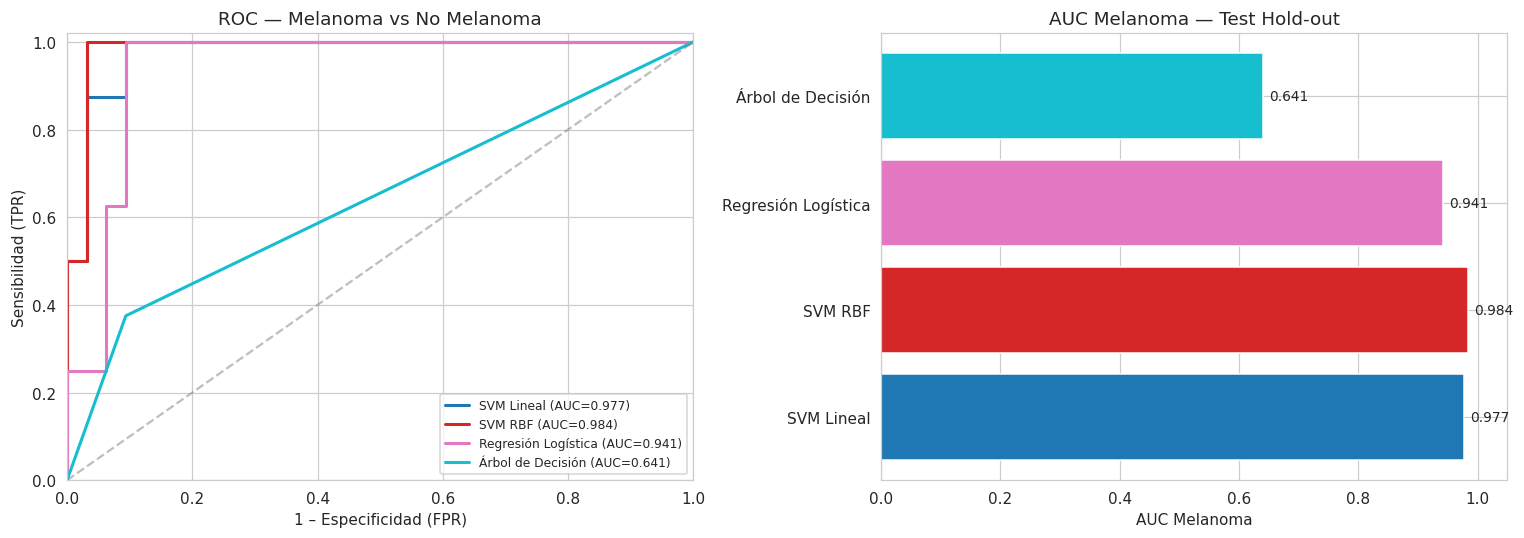

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
colores = plt.cm.tab10(np.linspace(0, 1, len(roc_data)))
for (nombre, (fpr, tpr, auc_val)), color in zip(roc_data.items(), colores):
    ax.plot(fpr, tpr, label=f"{nombre} (AUC={auc_val:.3f})", color=color, lw=2)
ax.plot([0,1],[0,1],"--", color="gray", alpha=0.5)
ax.set_xlabel("1 – Especificidad (FPR)")
ax.set_ylabel("Sensibilidad (TPR)")
ax.set_title("ROC — Melanoma vs No Melanoma")
ax.legend(fontsize=8)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])

ax2 = axes[1]
nombres = [r["Modelo"] for r in resultados_test]
aucs    = [r["AUC Melanoma"] for r in resultados_test]
colores_bar = plt.cm.tab10(np.linspace(0, 1, len(nombres)))
bars = ax2.barh(nombres, aucs, color=colores_bar, edgecolor="white")
ax2.set_xlim([0, 1.05])
ax2.set_xlabel("AUC Melanoma")
ax2.set_title("AUC Melanoma — Test Hold-out")
for bar, val in zip(bars, aucs):
    ax2.text(val + 0.01, bar.get_y() + bar.get_height()/2,
             f"{val:.3f}", va="center", fontsize=9)

plt.tight_layout()
plt.show()


## 12. Matrices de confusión (Test hold-out)

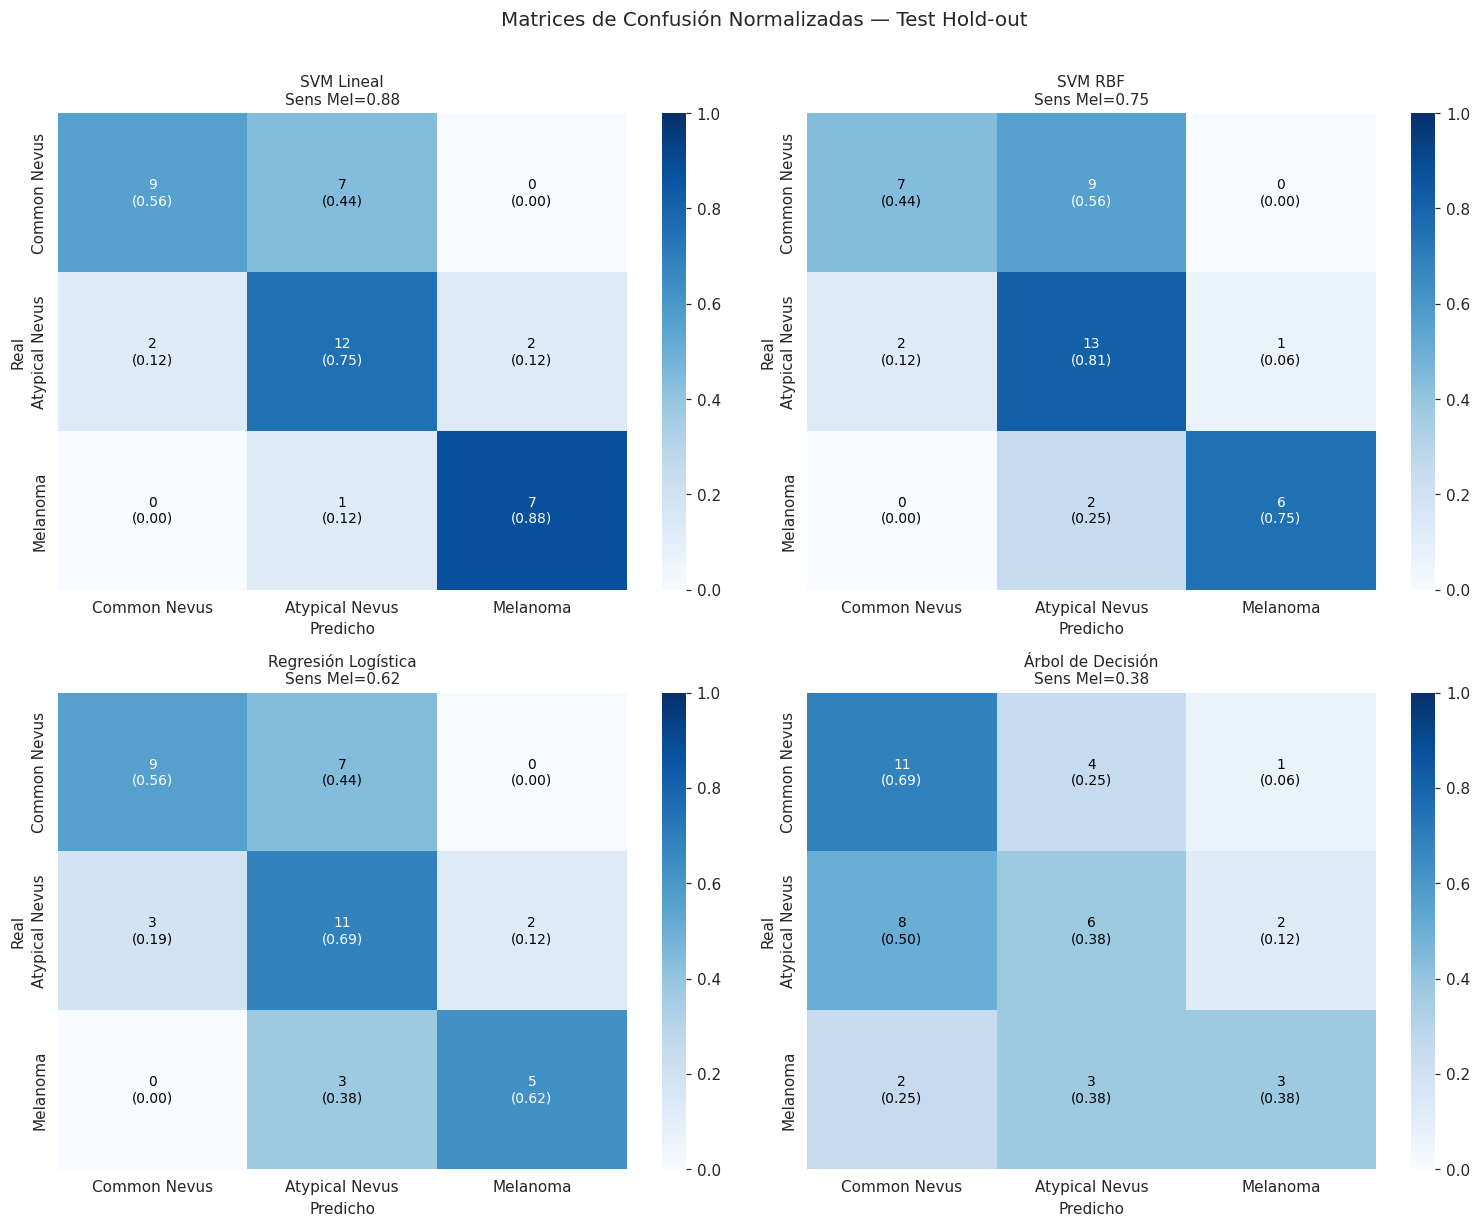

In [12]:
n_modelos = len(resultados_grid)
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
axes = axes.flatten()

for ax, (nombre, info) in zip(axes, resultados_grid.items()):
    modelo  = info["best_model"]
    y_pred  = modelo.predict(X_test)
    cm      = confusion_matrix(y_test, y_pred)

    # Normalizada
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    sns.heatmap(
        cm_norm, annot=False, cmap="Blues", cbar=True, ax=ax,
        xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
        vmin=0, vmax=1
    )
    # Anotaciones manuales: abs (norm)
    for i in range(len(CLASS_NAMES)):
        for j in range(len(CLASS_NAMES)):
            ax.text(j + 0.5, i + 0.5,
                    f"{cm[i,j]}\n({cm_norm[i,j]:.2f})",
                    ha="center", va="center", fontsize=9,
                    color="white" if cm_norm[i,j] > 0.5 else "black")

    acc_mel_class = cm_norm[2, 2]
    ax.set_title(f"{nombre}\nSens Mel={acc_mel_class:.2f}", fontsize=10)
    ax.set_xlabel("Predicho")
    ax.set_ylabel("Real")

# Ocultar subplot sobrante si hay < 4 modelos
for ax in axes[n_modelos:]:
    ax.axis("off")

plt.suptitle("Matrices de Confusión Normalizadas — Test Hold-out", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


## 13. Tabla comparativa final vs ResNet50 (experimentos previos)

Se incluyen los resultados de los experimentos más relevantes de `Modelamiento-2.ipynb`
para comparación directa.


In [13]:
# Referencia de experimentos ResNet (del archivo resultados_experimentos.csv)
resnet_ref = pd.DataFrame([
    {"Modelo": "ResNet50 Regularizada (Exp 6)",      "Accuracy": 0.675, "F1 Macro": 0.700,
     "F1 Melanoma": 0.857, "AUC Melanoma": 0.988, "Sensibilidad": 0.750, "Especificidad": 1.000},
    {"Modelo": "ResNet50 + TTA (Exp 13)",             "Accuracy": 0.675, "F1 Macro": 0.713,
     "F1 Melanoma": 0.941, "AUC Melanoma": 0.984, "Sensibilidad": 1.000, "Especificidad": 0.969},
    {"Modelo": "Ensemble Img+Tabular (Exp 14b)",      "Accuracy": 0.975, "F1 Macro": 0.968,
     "F1 Melanoma": 0.933, "AUC Melanoma": 0.996, "Sensibilidad": 0.875, "Especificidad": 1.000},
])

# ML clásico (resultados de este notebook)
ml_ref = pd.DataFrame([
    {k: v for k, v in r.items() if k in [
        "Modelo", "Accuracy", "F1 Macro", "F1 Melanoma",
        "AUC Melanoma", "Sensibilidad", "Especificidad"
    ]}
    for r in resultados_test
])

# Combinar
tabla_final = pd.concat([ml_ref, resnet_ref], ignore_index=True)
tabla_final["Tipo"] = (
    tabla_final["Modelo"]
    .apply(lambda x: "ML Clásico (deep features)" if x in ml_ref["Modelo"].values else "ResNet50 (referencia)")
)

# Ordenar por AUC Melanoma
tabla_final = tabla_final.sort_values("AUC Melanoma", ascending=False).reset_index(drop=True)

# Formatear
display(tabla_final.style
    .background_gradient(cmap="RdYlGn", subset=["AUC Melanoma", "F1 Melanoma", "Sensibilidad"])
    .format({
        "Accuracy"      : "{:.3f}",
        "F1 Macro"      : "{:.3f}",
        "F1 Melanoma"   : "{:.3f}",
        "AUC Melanoma"  : "{:.3f}",
        "Sensibilidad"  : "{:.3f}",
        "Especificidad" : "{:.3f}",
    })
)


,Modelo,Accuracy,F1 Macro,F1 Melanoma,AUC Melanoma,Sensibilidad,Especificidad,Tipo
0,Ensemble Img+Tabular (Exp 14b),0.975,0.968,0.933,0.996,0.875,1.000,ResNet50 (referencia)
1,ResNet50 Regularizada (Exp 6),0.675,0.700,0.857,0.988,0.750,1.000,ResNet50 (referencia)
2,SVM RBF,0.650,0.670,0.800,0.984,0.750,0.969,ML Clásico (deep features)
3,ResNet50 + TTA (Exp 13),0.675,0.713,0.941,0.984,1.000,0.969,ResNet50 (referencia)
4,SVM Lineal,0.700,0.719,0.824,0.977,0.875,0.938,ML Clásico (deep features)
5,Regresión Logística,0.625,0.635,0.667,0.941,0.625,0.938,ML Clásico (deep features)
6,Árbol de Decisión,0.500,0.479,0.429,0.641,0.375,0.906,ML Clásico (deep features)


## 14. Gráfico comparativo de métricas

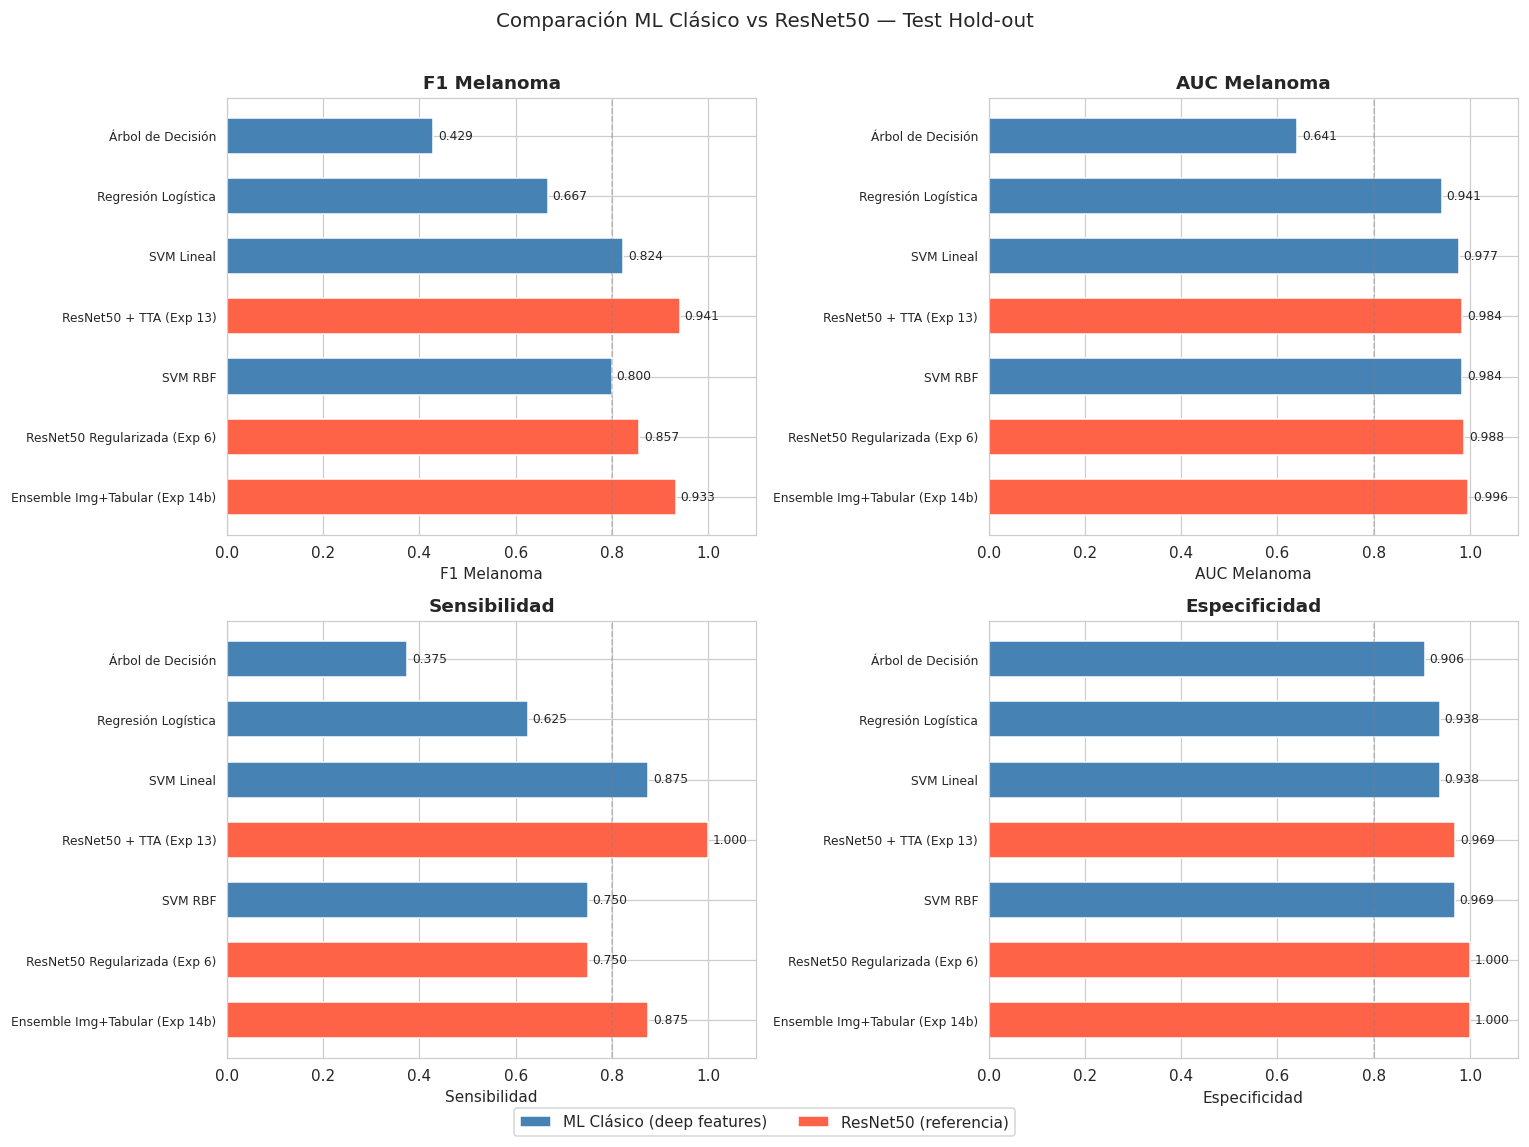

In [14]:
metricas_plot = ["F1 Melanoma", "AUC Melanoma", "Sensibilidad", "Especificidad"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

colores_tipo = {
    "ML Clásico (deep features)": "steelblue",
    "ResNet50 (referencia)"      : "tomato"
}

for ax, metrica in zip(axes, metricas_plot):
    valores = tabla_final[metrica].values
    nombres = tabla_final["Modelo"].values
    tipos   = tabla_final["Tipo"].values
    colors  = [colores_tipo[t] for t in tipos]

    bars = ax.barh(
        range(len(nombres)), valores,
        color=colors, edgecolor="white", height=0.6
    )
    ax.set_yticks(range(len(nombres)))
    ax.set_yticklabels(nombres, fontsize=8)
    ax.set_xlim([0, 1.1])
    ax.set_xlabel(metrica)
    ax.set_title(metrica, fontweight="bold")
    ax.axvline(x=0.8, color="gray", linestyle="--", alpha=0.4, lw=1)

    for bar, val in zip(bars, valores):
        ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
                f"{val:.3f}", va="center", fontsize=8)

# Leyenda manual
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="steelblue", label="ML Clásico (deep features)"),
    Patch(facecolor="tomato",    label="ResNet50 (referencia)")
]
fig.legend(handles=legend_elements, loc="lower center", ncol=2,
           bbox_to_anchor=(0.5, -0.02), fontsize=10)

plt.suptitle("Comparación ML Clásico vs ResNet50 — Test Hold-out", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()
